# Food Delivery Data Visualization Portfolio

This notebook uses Matplotlib and Seaborn to explore food-delivery business performance. It investigates time trends, city and cuisine performance, marketing and service relationships, order channels, weather, and customer behavior. Each section is followed by a concise interpretation of the visual evidence.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_PATH = Path('Day14_Food_Delivery_Visualization_Dataset.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df['Day'] = pd.Categorical(df['Day'], categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

sns.set_theme(style='whitegrid', palette='deep')
print(f'Dataset shape: {df.shape}')
display(df.head())
print('\nMissing values:')
display(df.isna().sum().to_frame('missing_values'))
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print('\nSummary statistics:')
display(df.describe(include='all').T)

Dataset shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9



Missing values:


,missing_values
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0



Duplicate rows: 0

Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_Batch_ID,360,360,FD0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,360,NaN,NaN,NaN,2025-06-30 21:32:00,2025-01-02 00:00:00,2025-04-05 12:00:00,2025-06-26 12:00:00,2025-09-25 12:00:00,2025-12-28 00:00:00,NaN
Month,360,12,June,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,360,7,Thursday,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,360,8,Bengaluru,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cuisine,360,6,Healthy,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Channel,360,3,App,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,360,4,Clear,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Orders,360.0,NaN,NaN,NaN,147.647222,58.0,123.75,147.0,169.0,235.0,33.387161
Average_Order_Value,360.0,NaN,NaN,NaN,409.151083,243.76,353.84,412.41,464.945,575.94,70.249186


## 1. Orders and Revenue Over Time

Aggregating by month reveals how demand and revenue change through the year.

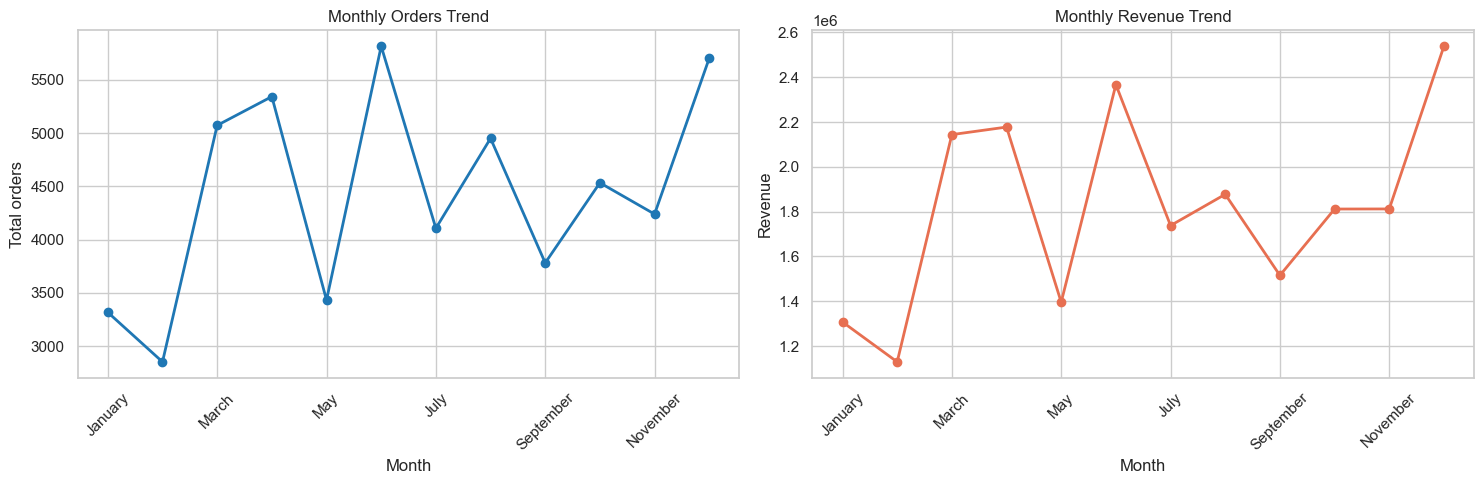

Interpretation: Orders peak in June (5,816) and revenue peaks in December (2,538,434.94).


In [3]:
monthly = df.groupby('Month', observed=False).agg(Orders=('Orders', 'sum'), Revenue=('Revenue', 'sum')).reindex(month_order)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
monthly['Orders'].plot(marker='o', linewidth=2, ax=axes[0], color='#1f77b4')
axes[0].set_title('Monthly Orders Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total orders')
axes[0].tick_params(axis='x', rotation=45)
monthly['Revenue'].plot(marker='o', linewidth=2, ax=axes[1], color='#e76f51')
axes[1].set_title('Monthly Revenue Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"Interpretation: Orders peak in {monthly['Orders'].idxmax()} ({monthly['Orders'].max():,.0f}) and revenue peaks in {monthly['Revenue'].idxmax()} ({monthly['Revenue'].max():,.2f}).")

## 2. City, Cuisine, Channel, and Weather Comparisons

Bar charts compare business performance, while count plots show how observations are distributed across operating categories.

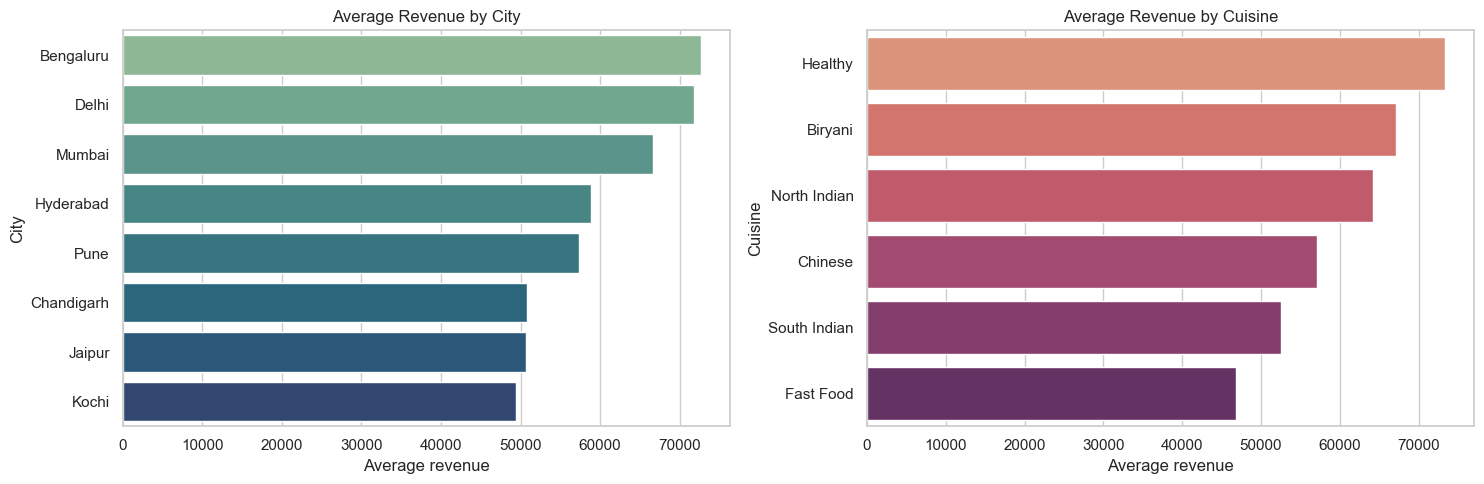

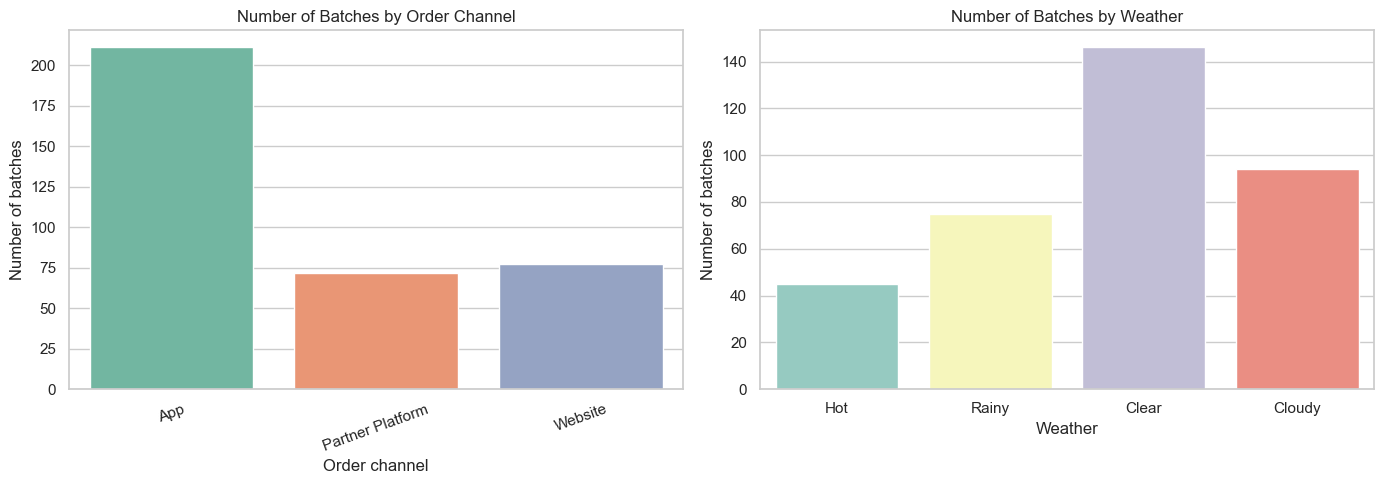

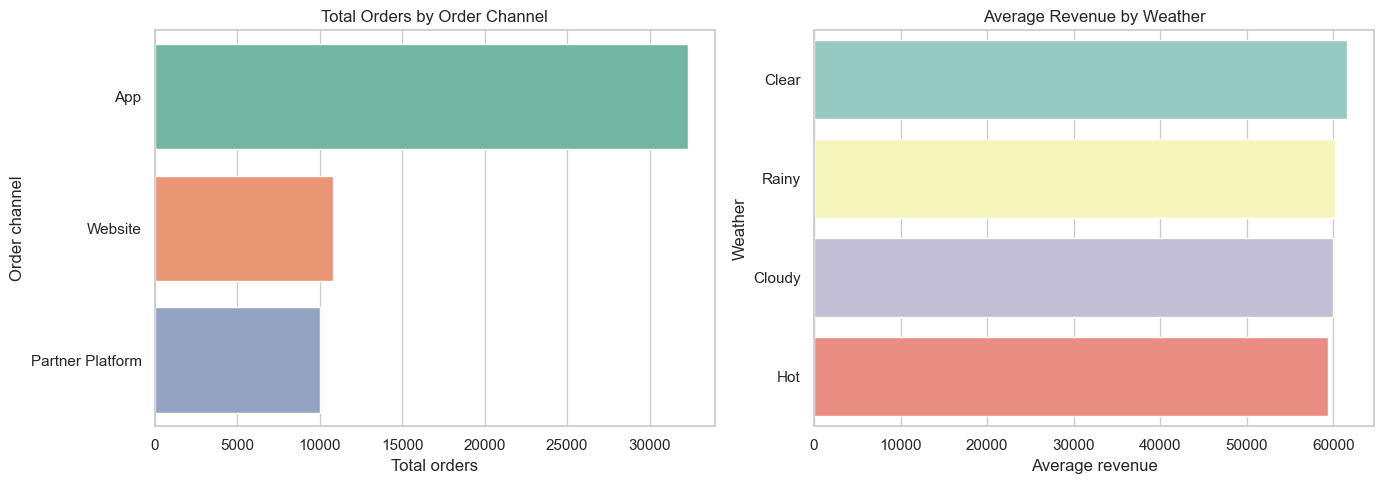

Interpretation: Bengaluru has the highest average city revenue, while Healthy leads cuisines. The count plots show that App and Clear are the most frequently observed categories. The performance charts show that App has the most total orders and Clear has the highest average revenue. These are descriptive comparisons, not causal effects.


In [8]:
city_summary = df.groupby('City', as_index=False).agg(Revenue=('Revenue', 'mean'), Orders=('Orders', 'mean')).sort_values('Revenue', ascending=False)
cuisine_summary = df.groupby('Cuisine', as_index=False).agg(Revenue=('Revenue', 'mean'), Orders=('Orders', 'mean')).sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=city_summary, x='Revenue', y='City', hue='City', legend=False, ax=axes[0], palette='crest')
axes[0].set_title('Average Revenue by City')
axes[0].set_xlabel('Average revenue')
axes[0].set_ylabel('City')
sns.barplot(data=cuisine_summary, x='Revenue', y='Cuisine', hue='Cuisine', legend=False, ax=axes[1], palette='flare')
axes[1].set_title('Average Revenue by Cuisine')
axes[1].set_xlabel('Average revenue')
axes[1].set_ylabel('Cuisine')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Order_Channel', hue='Order_Channel', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Number of Batches by Order Channel')
axes[0].set_xlabel('Order channel')
axes[0].set_ylabel('Number of batches')
axes[0].tick_params(axis='x', rotation=20)
sns.countplot(data=df, x='Weather', hue='Weather', legend=False, ax=axes[1], palette='Set3')
axes[1].set_title('Number of Batches by Weather')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Number of batches')
plt.tight_layout()
plt.show()

channel_performance = df.groupby('Order_Channel', as_index=False).agg(Total_Orders=('Orders', 'sum')).sort_values('Total_Orders', ascending=False)
weather_performance = df.groupby('Weather', as_index=False).agg(Average_Revenue=('Revenue', 'mean')).sort_values('Average_Revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=channel_performance, x='Total_Orders', y='Order_Channel', hue='Order_Channel', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Total Orders by Order Channel')
axes[0].set_xlabel('Total orders')
axes[0].set_ylabel('Order channel')
sns.barplot(data=weather_performance, x='Average_Revenue', y='Weather', hue='Weather', legend=False, ax=axes[1], palette='Set3')
axes[1].set_title('Average Revenue by Weather')
axes[1].set_xlabel('Average revenue')
axes[1].set_ylabel('Weather')
plt.tight_layout()
plt.show()

print(f"Interpretation: {city_summary.iloc[0]['City']} has the highest average city revenue, while {cuisine_summary.iloc[0]['Cuisine']} leads cuisines. The count plots show that {df['Order_Channel'].value_counts().idxmax()} and {df['Weather'].value_counts().idxmax()} are the most frequently observed categories. The performance charts show that {channel_performance.iloc[0]['Order_Channel']} has the most total orders and {weather_performance.iloc[0]['Weather']} has the highest average revenue. These are descriptive comparisons, not causal effects.")

## 3. Business and Service Relationships

Scatter plots test whether marketing investment is associated with revenue and whether delivery speed is associated with customer satisfaction.

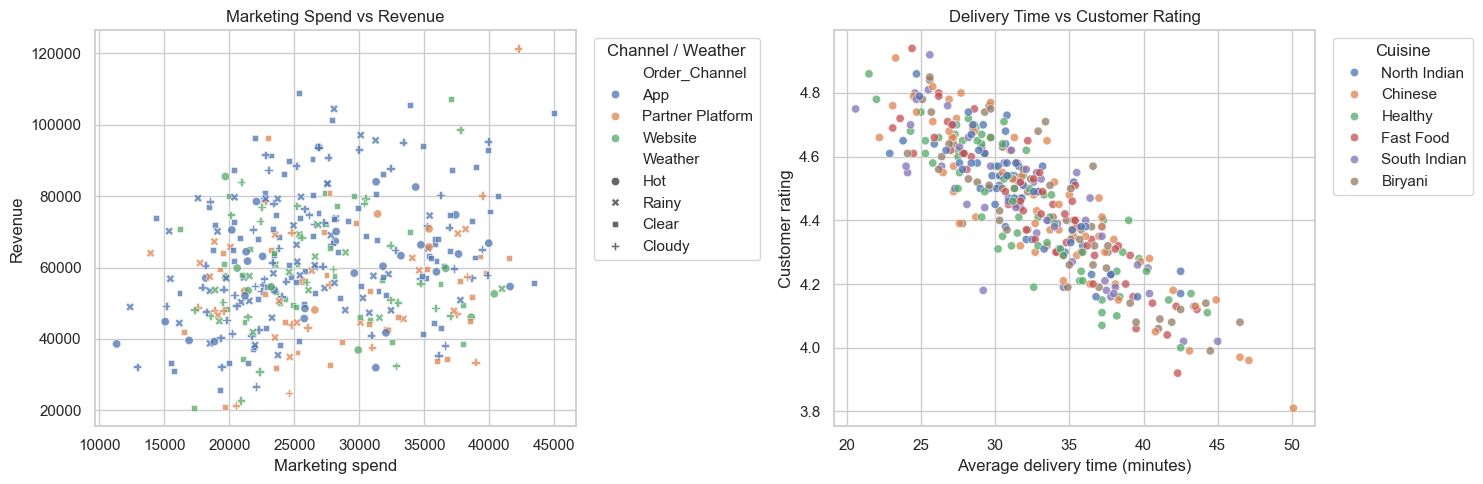

Interpretation: Marketing spend and revenue have a Pearson correlation of 0.20. Delivery time and rating have a correlation of -0.88; the direction suggests that longer delivery is generally associated with lower satisfaction.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='Marketing_Spend', y='Revenue', hue='Order_Channel', style='Weather', alpha=0.75, ax=axes[0])
axes[0].set_title('Marketing Spend vs Revenue')
axes[0].set_xlabel('Marketing spend')
axes[0].set_ylabel('Revenue')
axes[0].legend(title='Channel / Weather', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.scatterplot(data=df, x='Avg_Delivery_Minutes', y='Customer_Rating', hue='Cuisine', alpha=0.75, ax=axes[1])
axes[1].set_title('Delivery Time vs Customer Rating')
axes[1].set_xlabel('Average delivery time (minutes)')
axes[1].set_ylabel('Customer rating')
axes[1].legend(title='Cuisine', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

marketing_corr = df['Marketing_Spend'].corr(df['Revenue'])
delivery_corr = df['Avg_Delivery_Minutes'].corr(df['Customer_Rating'])
print(f'Interpretation: Marketing spend and revenue have a Pearson correlation of {marketing_corr:.2f}. Delivery time and rating have a correlation of {delivery_corr:.2f}; the direction suggests that longer delivery is generally associated with lower satisfaction.')

## 4. Distributions of Orders and Service Quality

Histograms show overall spread, box plots highlight city-level outliers, and violin plots compare the full rating distribution by channel.

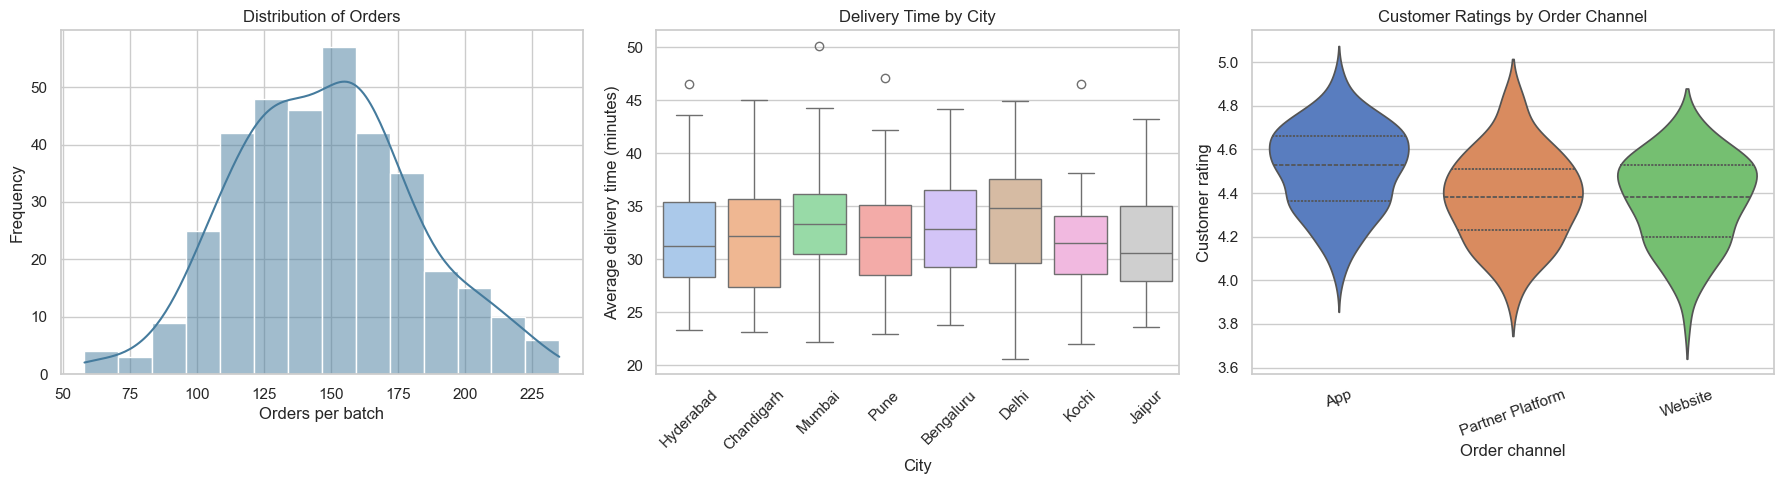

Interpretation: Orders average 147.6 per batch. The box plot shows that Delhi has the highest median delivery time (34.8 minutes), while also revealing city-level spread and outliers. The violin plot compares rating concentration and spread across channels; the App distribution is centered highest among the channels.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x='Orders', kde=True, color='#457b9d', ax=axes[0])
axes[0].set_title('Distribution of Orders')
axes[0].set_xlabel('Orders per batch')
axes[0].set_ylabel('Frequency')
sns.boxplot(data=df, x='City', y='Avg_Delivery_Minutes', hue='City', legend=False, ax=axes[1], palette='pastel')
axes[1].set_title('Delivery Time by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Average delivery time (minutes)')
axes[1].tick_params(axis='x', rotation=45)
sns.violinplot(data=df, x='Order_Channel', y='Customer_Rating', hue='Order_Channel', legend=False, ax=axes[2], palette='muted', inner='quartile')
axes[2].set_title('Customer Ratings by Order Channel')
axes[2].set_xlabel('Order channel')
axes[2].set_ylabel('Customer rating')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

city_median_delivery = df.groupby('City', observed=False)['Avg_Delivery_Minutes'].median().sort_values(ascending=False)
print(f"Interpretation: Orders average {df['Orders'].mean():.1f} per batch. The box plot shows that {city_median_delivery.index[0]} has the highest median delivery time ({city_median_delivery.iloc[0]:.1f} minutes), while also revealing city-level spread and outliers. The violin plot compares rating concentration and spread across channels; the App distribution is centered highest among the channels.")

## 5. Correlation Analysis and Key Findings

The heatmap summarizes linear relationships among the main business and customer-experience measures. Correlation indicates association, not causation.

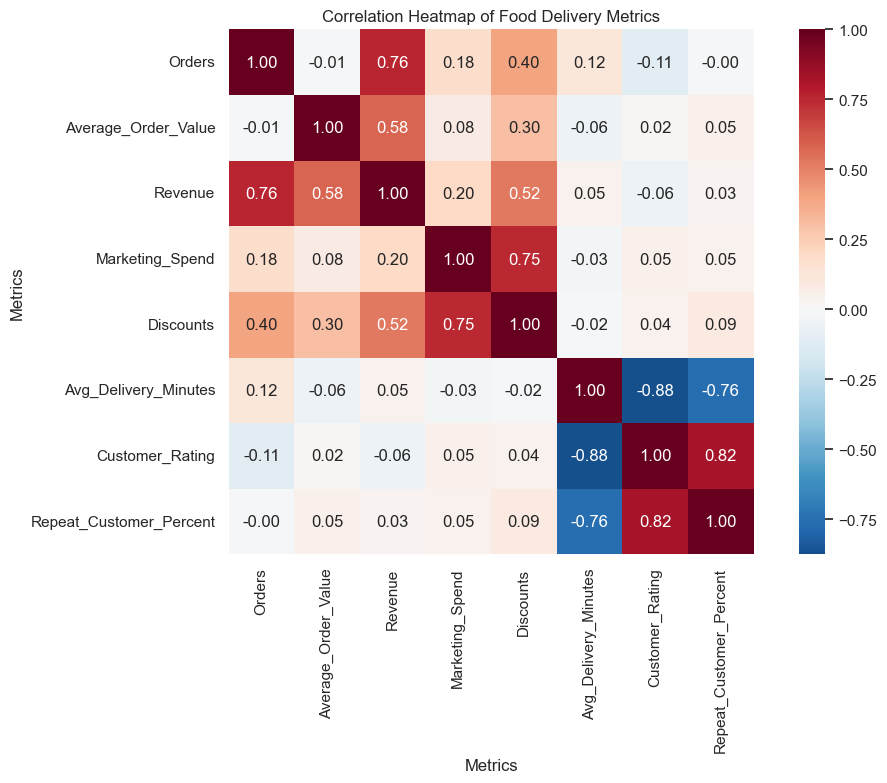

Key findings:
1. Revenue is most strongly related to orders (r=0.76) and average order value (r=0.58).
2. Marketing spend has a correlation of 0.20 with revenue, indicating a positive but imperfect association.
3. Bengaluru records the highest average revenue by city (72,678.47).
4. Healthy records the highest average revenue by cuisine (73,362.60).
5. App generates the most total orders (32,335) among the channels.
6. Delivery time and customer rating have a correlation of -0.88, suggesting slower delivery is associated with lower ratings.
7. Clear has the highest average revenue by weather condition (61,605.18); this is descriptive and may reflect differences in order mix.
8. The average customer rating is 4.45, while the average repeat-customer percentage is 41.6%.


In [10]:
correlation_columns = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap of Food Delivery Metrics')
plt.xlabel('Metrics')
plt.ylabel('Metrics')
plt.tight_layout()
plt.show()

def avg(column, group_column):
    return df.groupby(group_column, observed=False)[column].mean().sort_values(ascending=False)

city_revenue = avg('Revenue', 'City')
cuisine_revenue = avg('Revenue', 'Cuisine')
channel_orders = df.groupby('Order_Channel', observed=False)['Orders'].sum().sort_values(ascending=False)
weather_revenue = avg('Revenue', 'Weather')
print('Key findings:')
print(f"1. Revenue is most strongly related to orders (r={correlation_matrix.loc['Orders', 'Revenue']:.2f}) and average order value (r={correlation_matrix.loc['Average_Order_Value', 'Revenue']:.2f}).")
print(f"2. Marketing spend has a correlation of {correlation_matrix.loc['Marketing_Spend', 'Revenue']:.2f} with revenue, indicating a positive but imperfect association.")
print(f"3. {city_revenue.index[0]} records the highest average revenue by city ({city_revenue.iloc[0]:,.2f}).")
print(f"4. {cuisine_revenue.index[0]} records the highest average revenue by cuisine ({cuisine_revenue.iloc[0]:,.2f}).")
print(f"5. {channel_orders.index[0]} generates the most total orders ({channel_orders.iloc[0]:,.0f}) among the channels.")
print(f"6. Delivery time and customer rating have a correlation of {correlation_matrix.loc['Avg_Delivery_Minutes', 'Customer_Rating']:.2f}, suggesting slower delivery is associated with lower ratings.")
print(f"7. {weather_revenue.index[0]} has the highest average revenue by weather condition ({weather_revenue.iloc[0]:,.2f}); this is descriptive and may reflect differences in order mix.")
print(f"8. The average customer rating is {df['Customer_Rating'].mean():.2f}, while the average repeat-customer percentage is {df['Repeat_Customer_Percent'].mean():.1f}%.")